In [1]:
# Verify we hold the correct file context
print("File context verified.")

File context verified.


In [2]:
%pip install gensim
%pip install imbalanced-learn
%pip install pandas
%pip install openai python-dotenv
%pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
df = pd.read_csv("cleaned_file.csv", on_bad_lines='skip')

df.head()

,payload,classification
0,sullivanjj@state.gov,high
1,"Koh, Harold Hongju",high
2,"Dear customer, you have 16,590 points which wi...",low
3,mark.guzman@enron.com,high
4,"icd_code=0090, icd_version=9, diagnosis=Infect...",high


In [4]:
df = df.rename(columns={
    df.columns[0]: 'Tag',
    df.columns[1]: 'Sensitivity'
})

df['Sensitivity'] = (
    df['Sensitivity']
        .astype(str)          # ensure string
        .str.strip()          # remove spaces
        .str.capitalize()     # High / Low format
)




In [5]:
print(df['Sensitivity'].value_counts())

Sensitivity
High    5876
Low     4425
Name: count, dtype: int64


In [6]:
print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9393


In [7]:
df = df.dropna(subset=['Sensitivity'])
df = df.drop_duplicates(subset='Tag', keep=False)

df.shape[0]

print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9006


In [8]:
import re
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[=;:/\\._,\]\'"{}#%!<>$+()&-]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if not re.search(r'\d', t)]  # remove tokens with numbers
    tokens = [t for t in tokens if not re.search(r'^[a-f0-9:,]+$', t)]  # remove hex/timestamp tokens

    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [9]:
from sklearn.model_selection import train_test_split

X = df['Tag']
y = df['Sensitivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)


In [10]:
print(X_train)

2036    UPS: Your package requires teriyaki sauce appr...
9792    cfips=13179; name=Liberty; long=-81.49463778; ...
5056    icd_code: G35, icd_version: 10, diagnosis: Mul...
8586    icd_code=Z31.63, icd_version=10, diagnosis=Enc...
1435    Your Twitter Circle new members. Welcome: http...
                              ...                        
589     UPS: Your package requires age verification. V...
1734    patient: Sarah Wilson, condition: Hyperornithi...
2465    Your AT&T wireless service has been suspended....
4433    $7,800 BlueStar Range! Claim: http://bluestar-...
2572                                     O'Neil, Claire T
Name: Tag, Length: 7204, dtype: object


In [11]:
#X_train_sample = X_train.apply(preprocess_text)
#print (X_train_sample)

In [12]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.preprocessing import FunctionTransformer
from imblearn.over_sampling import SMOTE

def whitespace_at_tokenizer(text):
    text = text.lower()
    tokens = re.split(r'(\@)', text)
    result = []
    for part in tokens:
        if part == '@':
            result.append(part)
        else:
            result += part.split()
    return [t for t in result if t.strip()]

count_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r"(?u)\b\w{2,}\b|@",
    ngram_range=(2,3),
    max_features=5000,
    min_df=2,
    preprocessor=preprocess_text,
    stop_words='english'
)

X_train_vec = count_vectorizer.fit_transform(X_train)
X_test_vec  = count_vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_vec, y_train)

print(pd.Series(y_resampled).value_counts())

Sensitivity
Low     3900
High    3900
Name: count, dtype: int64


In [13]:
import numpy as np
import pandas as pd
import re

sample_df = df[['Tag', 'Sensitivity']].sample(5, random_state=21).reset_index(drop=True)

def whitespace_at_tokenizer(text):
    text = text.lower()
    tokens = re.split(r'(\@)', text)
    result = []
    for part in tokens:
        if part == '@':
            result.append(part)
        else:
            result += part.split()
    return [t for t in result if t.strip()]

def show_word_tokens(text):
    tokens = whitespace_at_tokenizer(text)
    result = []
    # unigrams
    result += tokens
    # bigrams
    result += [f'{tokens[i]} {tokens[i+1]}' for i in range(len(tokens) - 1)]
    return result

sample_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r"(?u)\b\w{2,}\b|@",
    ngram_range=(2, 3),
    max_features=5000,
    min_df=1,
    preprocessor=preprocess_text,
    stop_words='english'
)

sample_df['Tag_Preprocessed'] = sample_df['Tag'].apply(preprocess_text)

sample_vectorizer.fit(sample_df['Tag'])

sample_df['Word_Tokenized'] = sample_df['Tag_Preprocessed'].apply(show_word_tokens)

sample_df['Word_Vectorized'] = sample_df['Tag'].apply(
    lambda x: sample_vectorizer.transform([x]).toarray()[0]
)

pd.set_option('display.max_colwidth', None)
sample_df[['Tag', 'Sensitivity', 'Word_Tokenized', 'Word_Vectorized']]

,Tag,Sensitivity,Word_Tokenized,Word_Vectorized
0,"bluetooth: JBL Reflect Flow Pro+ Sports Pro Max, mac: 33:22:11:00:99:88, sports_pro_max: yes",High,"[bluetooth, jbl, reflect, flow, pro, sports, pro, max, mac, sports, pro, max, yes, bluetooth jbl, jbl reflect, reflect flow, flow pro, pro sports, sports pro, pro max, max mac, mac sports, sports pro, pro max, max yes]","[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,"WIFI_CONFIG: Conference_VPN, Password: C0nf_VPN_P@$$2025, Security: WPA3",High,"[wifi, config, conference, vpn, password, vpn, p, @, security, wifi config, config conference, conference vpn, vpn password, password vpn, vpn p, p @, @ security]","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1]"
2,"bluetooth_pairing: Sony WH-1000XM5, mac: 5C:2F:8A:7E:1B:4D, user: seattle.agent@fbi.gov",High,"[bluetooth, pairing, sony, wh, mac, user, seattle, agent, @, fbi, gov, bluetooth pairing, pairing sony, sony wh, wh mac, mac user, user seattle, seattle agent, agent @, @ fbi, fbi gov]","[1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]"
3,"id:36100, customer_id:77812, phone_number:081445678901, reference_number:INV-250824153025, net_amount:2050000, status:01, paying_at:2025-08-24T00:00:00Z",High,"[id, customer, id, phone, number, reference, number, inv, net, amount, status, paying, at, id customer, customer id, id phone, phone number, number reference, reference number, number inv, inv net, net amount, amount status, status paying, paying at]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"$7,500 Bora Bora Overwater Bungalow Giveaway! Enter: http://borabora-bungalow-giveaway.com",Low,"[bora, bora, overwater, bungalow, giveaway, enter, http, borabora, bungalow, giveaway, com, bora bora, bora overwater, overwater bungalow, bungalow giveaway, giveaway enter, enter http, http borabora, borabora bungalow, bungalow giveaway, giveaway com]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [14]:
def show_ngrams(text):
    tokens = whitespace_at_tokenizer(text)
    result = []
    result += [f'{tokens[i]} {tokens[i+1]}' for i in range(len(tokens) - 1)]
    result += [f'{tokens[i]} {tokens[i+1]} {tokens[i+2]}' for i in range(len(tokens) - 2)]
    return result

sample_df['Word_NGrams'] = sample_df['Tag_Preprocessed'].apply(show_ngrams)

pd.set_option('display.max_colwidth', None)
sample_df[['Tag', 'Word_Tokenized', 'Word_NGrams', 'Word_Vectorized']]


,Tag,Word_Tokenized,Word_NGrams,Word_Vectorized
0,"bluetooth: JBL Reflect Flow Pro+ Sports Pro Max, mac: 33:22:11:00:99:88, sports_pro_max: yes","[bluetooth, jbl, reflect, flow, pro, sports, pro, max, mac, sports, pro, max, yes, bluetooth jbl, jbl reflect, reflect flow, flow pro, pro sports, sports pro, pro max, max mac, mac sports, sports pro, pro max, max yes]","[bluetooth jbl, jbl reflect, reflect flow, flow pro, pro sports, sports pro, pro max, max mac, mac sports, sports pro, pro max, max yes, bluetooth jbl reflect, jbl reflect flow, reflect flow pro, flow pro sports, pro sports pro, sports pro max, pro max mac, max mac sports, mac sports pro, sports pro max, pro max yes]","[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,"WIFI_CONFIG: Conference_VPN, Password: C0nf_VPN_P@$$2025, Security: WPA3","[wifi, config, conference, vpn, password, vpn, p, @, security, wifi config, config conference, conference vpn, vpn password, password vpn, vpn p, p @, @ security]","[wifi config, config conference, conference vpn, vpn password, password vpn, vpn p, p @, @ security, wifi config conference, config conference vpn, conference vpn password, vpn password vpn, password vpn p, vpn p @, p @ security]","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1]"
2,"bluetooth_pairing: Sony WH-1000XM5, mac: 5C:2F:8A:7E:1B:4D, user: seattle.agent@fbi.gov","[bluetooth, pairing, sony, wh, mac, user, seattle, agent, @, fbi, gov, bluetooth pairing, pairing sony, sony wh, wh mac, mac user, user seattle, seattle agent, agent @, @ fbi, fbi gov]","[bluetooth pairing, pairing sony, sony wh, wh mac, mac user, user seattle, seattle agent, agent @, @ fbi, fbi gov, bluetooth pairing sony, pairing sony wh, sony wh mac, wh mac user, mac user seattle, user seattle agent, seattle agent @, agent @ fbi, @ fbi gov]","[1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]"
3,"id:36100, customer_id:77812, phone_number:081445678901, reference_number:INV-250824153025, net_amount:2050000, status:01, paying_at:2025-08-24T00:00:00Z","[id, customer, id, phone, number, reference, number, inv, net, amount, status, paying, at, id customer, customer id, id phone, phone number, number reference, reference number, number inv, inv net, net amount, amount status, status paying, paying at]","[id customer, customer id, id phone, phone number, number reference, reference number, number inv, inv net, net amount, amount status, status paying, paying at, id customer id, customer id phone, id phone number, phone number reference, number reference number, reference number inv, number inv net, inv net amount, net amount status, amount status paying, status paying at]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,"$7,500 Bora Bora Overwater Bungalow Giveaway! Enter: http://borabora-bungalow-giveaway.com","[bora, bora, overwater, bungalow, giveaway, enter, http, borabora, bungalow, giveaway, com, bora bora, bora overwater, overwater bungalow, bungalow giveaway, giveaway enter, enter http, http borabora, borabora bungalow, bungalow giveaway, giveaway com]","[bora bora, bora overwater, overwater bungalow, bungalow giveaway, giveaway ent

In [15]:
sample_df[['Tag', 'Word_Tokenized']]

,Tag,Word_Tokenized
0,"bluetooth: JBL Reflect Flow Pro+ Sports Pro Max, mac: 33:22:11:00:99:88, sports_pro_max: yes","[bluetooth, jbl, reflect, flow, pro, sports, pro, max, mac, sports, pro, max, yes, bluetooth jbl, jbl reflect, reflect flow, flow pro, pro sports, sports pro, pro max, max mac, mac sports, sports pro, pro max, max yes]"
1,"WIFI_CONFIG: Conference_VPN, Password: C0nf_VPN_P@$$2025, Security: WPA3","[wifi, config, conference, vpn, password, vpn, p, @, security, wifi config, config conference, conference vpn, vpn password, password vpn, vpn p, p @, @ security]"
2,"bluetooth_pairing: Sony WH-1000XM5, mac: 5C:2F:8A:7E:1B:4D, user: seattle.agent@fbi.gov","[bluetooth, pairing, sony, wh, mac, user, seattle, agent, @, fbi, gov, bluetooth pairing, pairing sony, sony wh, wh mac, mac user, user seattle, seattle agent, agent @, @ fbi, fbi gov]"
3,"id:36100, customer_id:77812, phone_number:081445678901, reference_number:INV-250824153025, net_amount:2050000, status:01, paying_at:2025-08-24T00:00:00Z","[id, customer, id, phone, number, reference, number, inv, net, amount, status, paying, at, id customer, customer id, id phone, phone number, number reference, reference number, number inv, inv net, net amount, amount status, status paying, paying at]"
4,"$7,500 Bora Bora Overwater Bungalow Giveaway! Enter: http://borabora-bungalow-giveaway.com","[bora, bora, overwater, bungalow, giveaway, enter, http, borabora, bungalow, giveaway, com, bora bora, bora overwater, overwater bungalow, bungalow giveaway, giveaway enter, enter http, http borabora, borabora bungalow, bungalow giveaway, giveaway com]"


In [16]:
sample_df['Word_NGrams']

0                                                                [bluetooth jbl, jbl reflect, reflect flow, flow pro, pro sports, sports pro, pro max, max mac, mac sports, sports pro, pro max, max yes, bluetooth jbl reflect, jbl reflect flow, reflect flow pro, flow pro sports, pro sports pro, sports pro max, pro max mac, max mac sports, mac sports pro, sports pro max, pro max yes]
1                                                                                                                                                         [wifi config, config conference, conference vpn, vpn password, password vpn, vpn p, p @, @ security, wifi config conference, config conference vpn, conference vpn password, vpn password vpn, password vpn p, vpn p @, p @ security]
2                                                                                                                          [bluetooth pairing, pairing sony, sony wh, wh mac, mac user, user seattle, seattle agent, agent @, @ fbi, fbi

In [17]:
sample_df['Word_Vectorized']

0    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
2    [1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]
3    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0

In [18]:
ngram_df = pd.DataFrame({
    'ngram': count_vectorizer.get_feature_names_out(),
    'feature_index': range(len(count_vectorizer.get_feature_names_out()))
})

print(ngram_df.head)

<bound method NDFrame.head of                       ngram  feature_index
0                       @ @              0
1                     @ @ @              1
2              @ @ security              2
3                     @ bcm              3
4                 @ bcm edu              4
...                     ...            ...
4995  yesterday sleep score           4995
4996         yesterday sync           4996
4997            yeti cooler           4997
4998          zelle payment           4998
4999           zoom account           4999

[5000 rows x 2 columns]>


[('long lat', 805), ('icd code', 600), ('code icd version', 519), ('version diagnosis', 519), ('icd code icd', 519), ('code icd', 519), ('icd version', 519), ('icd version diagnosis', 519), ('bluetooth device', 498), ('password security', 456), ('https www', 418), ('pro max', 380), ('max ultra', 318), ('pro max ultra', 318), ('longitude latitude', 316), ('wifi config', 316), ('bluetooth pairing', 290), ('mac user', 271), ('pin connected', 245), ('mac address', 224)]


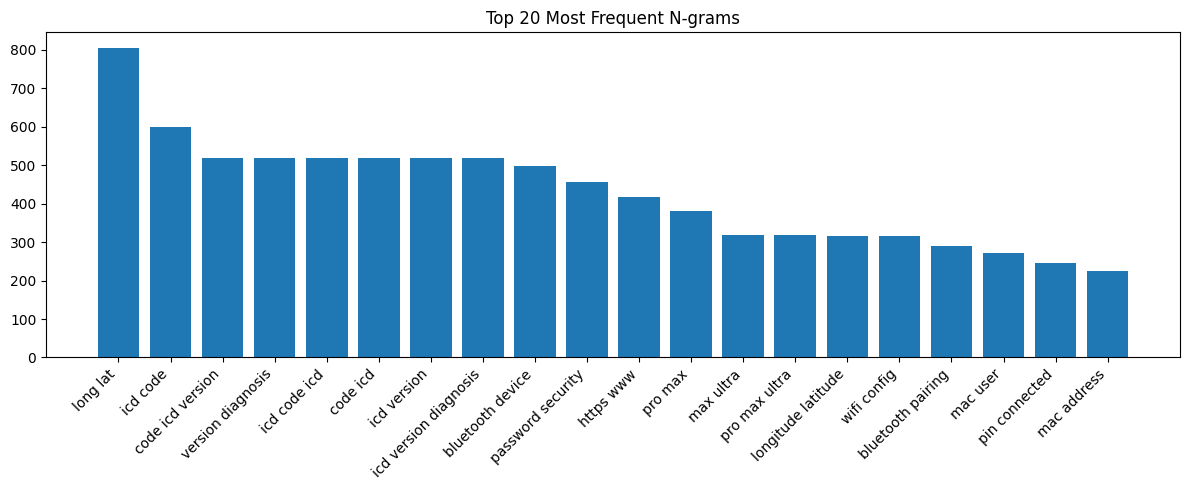

In [19]:
import matplotlib.pyplot as plt

ngram_freq = X_train_vec.sum(axis=0).A1
ngram_names = count_vectorizer.get_feature_names_out()

top_n = 20
top_idx = ngram_freq.argsort()[::-1][:top_n]

top_ngrams = [(ngram_names[i], ngram_freq[i]) for i in top_idx]
print(top_ngrams)

plt.figure(figsize=(12, 5))
plt.bar(ngram_names[top_idx], ngram_freq[top_idx])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent N-grams')
plt.tight_layout()
plt.show()

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline
clf = DecisionTreeClassifier(random_state=38)
clf.fit(X_resampled, y_resampled)

y_pred_cv = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred_cv))

dt_f1_macro = f1_score(y_test, y_pred_cv, average='macro')
dt_accuracy  = accuracy_score(y_test, y_pred_cv)
print(f"Decision Tree Macro F1-score: {dt_f1_macro:.6f}")
print(f"Decision Tree Accuracy:       {dt_accuracy:.6f}")

clf_pipeline_cv = Pipeline([
    ("count_vectorizer", CountVectorizer(
        analyzer='word',
        token_pattern=r"(?u)\b\w{2,}\b|@",
        preprocessor=preprocess_text,
        stop_words='english'
    )),
    ("clf", DecisionTreeClassifier(random_state=38))
])

              precision    recall  f1-score   support

        High       0.98      0.99      0.98       975
         Low       0.98      0.97      0.98       827

    accuracy                           0.98      1802
   macro avg       0.98      0.98      0.98      1802
weighted avg       0.98      0.98      0.98      1802

Decision Tree Macro F1-score: 0.979306
Decision Tree Accuracy:       0.979467


In [21]:
import os

graphviz_paths = [
    r"C:\Program Files\Graphviz\bin",
    r"C:\Program Files (x86)\Graphviz\bin",
]

for p in graphviz_paths:
    if os.path.isdir(p) and p not in os.environ.get("PATH", ""):
        os.environ["PATH"] += os.pathsep + p
        print(f"Added to PATH: {p}")


In [22]:
from sklearn.tree import export_graphviz
import graphviz
from datetime import datetime

tree_model = clf       
vectorizer = count_vectorizer  

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=tree_model.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True,
)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = "decision_tree_untuned"

graph = graphviz.Source(dot_data)
graph.render(filename, format="pdf", view=True)
print(f"Exported: {filename}.pdf")

Exported: decision_tree_untuned.pdf


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

clf_knn = KNeighborsClassifier(n_neighbors=10)
clf_knn.fit(X_resampled, y_resampled) # Pass raw resampled data here

# Use the vectorized test data directly
y_pred_knn = clf_knn.predict(X_test_vec) 

print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, y_pred_knn))

knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')
knn_accuracy  = accuracy_score(y_test, y_pred_knn)
print(f"KNN Macro F1-score: {knn_f1_macro:.6f}")
print(f"KNN Accuracy:       {knn_accuracy:.6f}")
clf_pipeline_knn = Pipeline([
    ("count_vectorizer", CountVectorizer(
        analyzer='word',
        token_pattern=r"(?u)\b\w{2,}\b|@",
        preprocessor=preprocess_text,
        stop_words='english'
    )),
    ("clf", KNeighborsClassifier(n_neighbors=10))
])

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

        High       0.94      0.94      0.94       975
         Low       0.93      0.93      0.93       827

    accuracy                           0.93      1802
   macro avg       0.93      0.93      0.93      1802
weighted avg       0.93      0.93      0.93      1802

KNN Macro F1-score: 0.932943
KNN Accuracy:       0.933407


In [24]:
from sklearn.naive_bayes import MultinomialNB

clf_nb = MultinomialNB()
clf_nb.fit(X_resampled, y_resampled)

y_pred_nb = clf_nb.predict(X_test_vec)
print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

nb_f1_macro = f1_score(y_test, y_pred_nb, average='macro')
nb_accuracy  = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Macro F1-score: {nb_f1_macro:.6f}")
print(f"Naive Bayes Accuracy:       {nb_accuracy:.6f}")

clf_pipeline_nb = Pipeline([
    ("count_vectorizer", CountVectorizer(
        analyzer='word',
        token_pattern=r"(?u)\b\w{2,}\b|@",
        preprocessor=preprocess_text,
        stop_words='english'
    )),
    ("clf", MultinomialNB())
])

=== Naive Bayes ===
              precision    recall  f1-score   support

        High       0.98      0.99      0.98       975
         Low       0.98      0.98      0.98       827

    accuracy                           0.98      1802
   macro avg       0.98      0.98      0.98      1802
weighted avg       0.98      0.98      0.98      1802

Naive Bayes Macro F1-score: 0.982115
Naive Bayes Accuracy:       0.982242


In [25]:
from sklearn.model_selection import GridSearchCV
from datetime import datetime


param_grid_dt = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [17,18,19,20],
    "clf__min_samples_split": [2,3,4],
    "clf__min_samples_leaf": [2,3,4],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3,4), (4,5)],
    "count_vectorizer__max_features": [1750,2000,2250]
}

grid_search = GridSearchCV(
    clf_pipeline_cv,
    param_grid=param_grid_dt,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== DT Grid Search Results =====\n")
    f.write(f"Time: {datetime.now()}\n")
    f.write(f"Grid: {param_grid_dt}\n")
    f.write(f"Best Params: {grid_search.best_params_}\n")
    f.write(f"Best Score: {grid_search.best_score_}\n\n")


Best parameters found:  {'clf__criterion': 'entropy', 'clf__max_depth': 18, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'count_vectorizer__max_features': 1750, 'count_vectorizer__ngram_range': (1, 2)}
Best F1 score:  0.992165707559714

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      1.00      0.99       975
         Low       1.00      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9922308546059934


In [27]:
param_grid_knn = {
    "clf__n_neighbors": [2,3,4,5],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"],
    "count_vectorizer__ngram_range": [(1,2), (2,3), (3,4)],
    "count_vectorizer__max_features": [1250,1500,1750]

}

grid_knn = GridSearchCV(
    clf_pipeline_knn,
    param_grid=param_grid_knn,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_model = grid_knn.best_estimator_
print("Best KNN params:", grid_knn.best_params_)
print("Best CV F1 Score:", grid_knn.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== KNN Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_knn}\n")
    f.write(f"Best Params: {grid_knn.best_params_}\n")
    f.write(f"Best Score: {grid_knn.best_score_}\n\n")



Best KNN params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 4, 'clf__weights': 'distance', 'count_vectorizer__max_features': 1500, 'count_vectorizer__ngram_range': (1, 2)}
Best CV F1 Score: 0.9896488875687519

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.98      1.00      0.99       975
         Low       1.00      0.98      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9889012208657048


In [28]:
param_grid_nb = {
    "clf__alpha": [0.2,0.1,0.09],
    "clf__fit_prior": [True, False],
    "clf__force_alpha": [True, False],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3, 4)],
    "count_vectorizer__max_features": [1750,2000,2250]


}

grid_nb = GridSearchCV(
    clf_pipeline_nb,
    param_grid=param_grid_nb,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)
best_model = grid_nb.best_estimator_

print("Best Naive Bayes params:", grid_nb.best_params_)
print("Best CV accuracy:", grid_nb.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== NB Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_nb}\n")

    f.write(f"Best Params: {grid_nb.best_params_}\n")
    f.write(f"Best Score: {grid_nb.best_score_}\n\n")



Best Naive Bayes params: {'clf__alpha': 0.1, 'clf__fit_prior': False, 'clf__force_alpha': True, 'count_vectorizer__max_features': 2250, 'count_vectorizer__ngram_range': (1, 2)}
Best CV accuracy: 0.989231471718445

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      0.99      0.99       975
         Low       0.99      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9911209766925638


In [29]:
from sklearn.tree import export_graphviz
import graphviz

tree_model  = grid_search.best_estimator_.named_steps["clf"]
vectorizer  = grid_search.best_estimator_.named_steps["count_vectorizer"]

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=tree_model.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=19
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree_tuned", format="pdf", view=True)


'decision_tree_tuned.pdf'

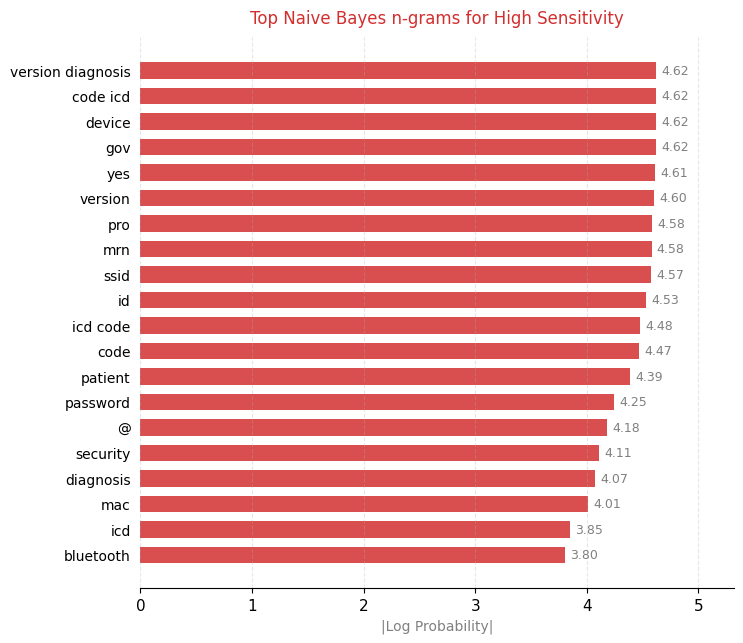

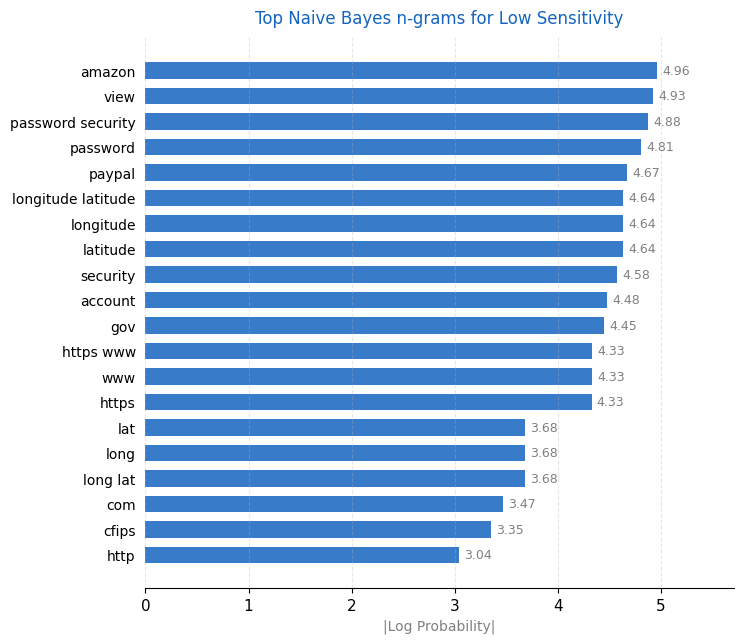

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Style setup
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

vectorizer = grid_nb.best_estimator_.named_steps['count_vectorizer']
clf_nb = grid_nb.best_estimator_.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
class_0_probs = clf_nb.feature_log_prob_[0]
class_1_probs = clf_nb.feature_log_prob_[1]

top_n = 20
top_class_0_idx = np.argsort(class_0_probs)[::-1][:top_n]
top_class_1_idx = np.argsort(class_1_probs)[::-1][:top_n]

# Use absolute values so bars read left-to-right naturally
class_0_vals = np.abs(class_0_probs[top_class_0_idx])
class_1_vals = np.abs(class_1_probs[top_class_1_idx])
class_0_labels = [feature_names[i] for i in top_class_0_idx]
class_1_labels = [feature_names[i] for i in top_class_1_idx]

def plot_ngrams(ax, values, labels, color, title):
    ax.barh(range(top_n), values, color=color, alpha=0.85, height=0.65)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='medium', pad=10, color=color)
    ax.set_xlabel("|Log Probability|", fontsize=10, color='gray')
    ax.yaxis.grid(False)
    ax.xaxis.grid(True)
    ax.tick_params(left=False)

    # Value labels at end of each bar
    for i, v in enumerate(values):
        ax.text(v + max(values) * 0.01, i, f'{v:.2f}',
                va='center', fontsize=9, color='gray')

    # Extend x-axis slightly to make room for labels
    ax.set_xlim(0, max(values) * 1.15)

# --- Class: High ---
fig1, ax1 = plt.subplots(figsize=(8, 7))
plot_ngrams(ax1, class_0_vals, class_0_labels, color='#D32F2F', title='Top Naive Bayes n-grams for High Sensitivity')
plt.tight_layout(pad=2.5)
plt.savefig('ngram_high.png', dpi=300, bbox_inches='tight')
plt.savefig('ngram_high.pdf', bbox_inches='tight')
plt.show()

# --- Class: Low ---
fig2, ax2 = plt.subplots(figsize=(8, 7))
plot_ngrams(ax2, class_1_vals, class_1_labels, color='#1565C0', title='Top Naive Bayes n-grams for Low Sensitivity')
plt.tight_layout(pad=2.5)
plt.savefig('ngram_low.png', dpi=300, bbox_inches='tight')
plt.savefig('ngram_low.pdf', bbox_inches='tight')
plt.show()

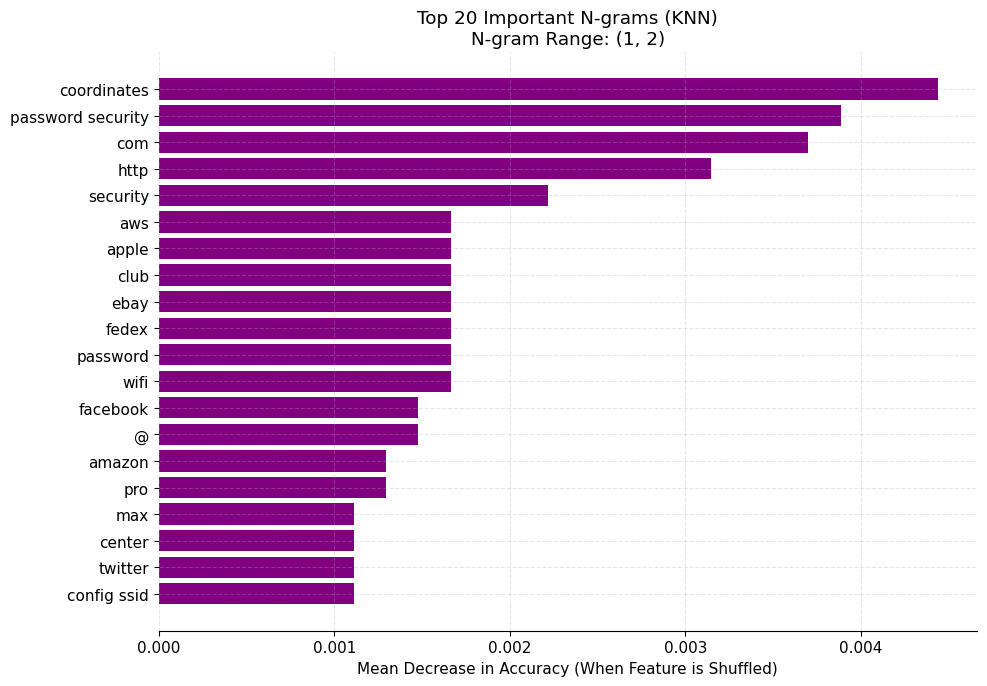

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

best_pipeline = grid_knn.best_estimator_
vectorizer = best_pipeline.named_steps['count_vectorizer']
feature_names = vectorizer.get_feature_names_out()
ngram_range = vectorizer.ngram_range

X_test_transformed = best_pipeline[:-1].transform(X_test).toarray()
y_test_subset = y_test

clf_knn = best_pipeline.named_steps['clf']

perm_result = permutation_importance(
    clf_knn,
    X_test_transformed,
    y_test_subset,
    scoring="accuracy",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

sorted_idx = np.argsort(perm_result.importances_mean)[::-1]
top_n = 20
top_idx = sorted_idx[:top_n]

plt.figure(figsize=(10, 7))
plt.barh(
    range(top_n),
    perm_result.importances_mean[top_idx][::-1],
    xerr= None,
    color='purple',
    align='center'
)
plt.yticks(range(top_n), feature_names[top_idx][::-1])
plt.xlabel("Mean Decrease in Accuracy (When Feature is Shuffled)")
plt.title(f"Top {top_n} Important N-grams (KNN)\nN-gram Range: {ngram_range}")
plt.tight_layout()
plt.savefig('knn_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.savefig('knn_permutation_importance.pdf', bbox_inches='tight')
plt.show()



In [30]:
import joblib

# The best performing model was the KNN model based on the GridSearchCV results.
best_model_to_export = grid_search.best_estimator_

# Define the filename for the exported model
model_filename = 'best_dt_model.joblib'

# Export the model
joblib.dump(best_model_to_export, model_filename)

print(f"Best model exported to {model_filename}")

Best model exported to best_dt_model.joblib


In [31]:
model2 = grid_knn.best_estimator_


model_filename = 'knn.joblib'

#joblib.dump(model2, model_filename)

#print(f"Model exported to {model_filename}")

model3 = grid_nb.best_estimator_

model_filename = 'nb.joblib'

#joblib.dump(model3, model_filename)

In [ ]:
# ==========================================
# FINAL EVALUATION CELL
# Includes Decision Tree, KNN, Naive Bayes, AND AI MODEL
# ==========================================

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd
import time

# --- AI IMPORT ---
from gpt4_classification import classify_batch_with_ai

import importlib
import gpt4_classification
importlib.reload(gpt4_classification)
from gpt4_classification import classify_batch_with_ai

print("STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...")

X_full = df['Tag']
y_full = df['Sensitivity']

dt_model = grid_search.best_estimator_
knn_model = grid_knn.best_estimator_
nb_model = grid_nb.best_estimator_

print("=" * 70)
print("3-Fold Cross-Validation with Different Train-Test Splits")
print("Using the FULL dataset with 3 different 80-20 splits")
print("=" * 70)

sss = StratifiedShuffleSplit(
    n_splits=3,
    test_size=0.2,
    train_size=0.8,
    random_state=42
)

# Initialize results dictionary including AI Model + timing
results = {
    'Decision Tree': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': [], 'time_per_sample': []},
    'KNN':           {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': [], 'time_per_sample': []},
    'Naive Bayes':   {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': [], 'time_per_sample': []},
    'AI Model':      {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': [], 'time_per_sample': []}
}

for fold_num, (train_idx, test_idx) in enumerate(sss.split(X_full, y_full), 1):
    print(f"\n{'='*70}")
    print(f"SPLIT {fold_num} - Training on {len(train_idx)} samples, Testing on {len(test_idx)} samples")
    print(f"{'='*70}")
    
    X_train_fold = X_full.iloc[train_idx]
    X_test_fold  = X_full.iloc[test_idx]
    y_train_fold = y_full.iloc[train_idx]
    y_test_fold  = y_full.iloc[test_idx]

    n_test = len(X_test_fold)

    print("Shape of X_train:", X_train_fold.shape)
    print("Shape of X_test:",  X_test_fold.shape)
    print("Shape of y_train:", y_train_fold.shape)
    print("Shape of y_test:",  y_test_fold.shape)
    
    # --- Decision Tree ---
    print("\n--- Decision Tree ---")
    dt_model.fit(X_train_fold, y_train_fold)
    t0 = time.perf_counter()
    y_pred_dt = dt_model.predict(X_test_fold)
    dt_elapsed = time.perf_counter() - t0
    dt_time_per_sample = (dt_elapsed / n_test) * 1000   # ms per sample

    dt_acc       = accuracy_score(y_test_fold, y_pred_dt)
    dt_f1        = f1_score(y_test_fold, y_pred_dt, average='macro')
    dt_precision = precision_score(y_test_fold, y_pred_dt, average='macro')
    dt_recall    = recall_score(y_test_fold, y_pred_dt, average='macro')
    
    results['Decision Tree']['accuracy'].append(dt_acc)
    results['Decision Tree']['f1_macro'].append(dt_f1)
    results['Decision Tree']['precision'].append(dt_precision)
    results['Decision Tree']['recall'].append(dt_recall)
    results['Decision Tree']['time_per_sample'].append(dt_time_per_sample)
    
    print(f"Accuracy: {dt_acc:.4f}, F1: {dt_f1:.4f}, Precision: {dt_precision:.4f}, Recall: {dt_recall:.4f}")
    print(f"Inference time: {dt_elapsed*1000:.2f} ms total | {dt_time_per_sample:.4f} ms/sample")
    
    # --- KNN ---
    print("\n--- K-Nearest Neighbors ---")
    knn_model.fit(X_train_fold, y_train_fold)
    t0 = time.perf_counter()
    y_pred_knn = knn_model.predict(X_test_fold)
    knn_elapsed = time.perf_counter() - t0
    knn_time_per_sample = (knn_elapsed / n_test) * 1000

    knn_acc       = accuracy_score(y_test_fold, y_pred_knn)
    knn_f1        = f1_score(y_test_fold, y_pred_knn, average='macro')
    knn_precision = precision_score(y_test_fold, y_pred_knn, average='macro')
    knn_recall    = recall_score(y_test_fold, y_pred_knn, average='macro')
    
    results['KNN']['accuracy'].append(knn_acc)
    results['KNN']['f1_macro'].append(knn_f1)
    results['KNN']['precision'].append(knn_precision)
    results['KNN']['recall'].append(knn_recall)
    results['KNN']['time_per_sample'].append(knn_time_per_sample)
    
    print(f"Accuracy: {knn_acc:.4f}, F1: {knn_f1:.4f}, Precision: {knn_precision:.4f}, Recall: {knn_recall:.4f}")
    print(f"Inference time: {knn_elapsed*1000:.2f} ms total | {knn_time_per_sample:.4f} ms/sample")
    
    # --- Naive Bayes ---
    print("\n--- Naive Bayes ---")
    nb_model.fit(X_train_fold, y_train_fold)
    t0 = time.perf_counter()
    y_pred_nb = nb_model.predict(X_test_fold)
    nb_elapsed = time.perf_counter() - t0
    nb_time_per_sample = (nb_elapsed / n_test) * 1000

    nb_acc       = accuracy_score(y_test_fold, y_pred_nb)
    nb_f1        = f1_score(y_test_fold, y_pred_nb, average='macro')
    nb_precision = precision_score(y_test_fold, y_pred_nb, average='macro')
    nb_recall    = recall_score(y_test_fold, y_pred_nb, average='macro')
    
    results['Naive Bayes']['accuracy'].append(nb_acc)
    results['Naive Bayes']['f1_macro'].append(nb_f1)
    results['Naive Bayes']['precision'].append(nb_precision)
    results['Naive Bayes']['recall'].append(nb_recall)
    results['Naive Bayes']['time_per_sample'].append(nb_time_per_sample)
    
    print(f"Accuracy: {nb_acc:.4f}, F1: {nb_f1:.4f}, Precision: {nb_precision:.4f}, Recall: {nb_recall:.4f}")
    print(f"Inference time: {nb_elapsed*1000:.2f} ms total | {nb_time_per_sample:.4f} ms/sample")

    # --- AI Model ---
    print("\n--- AI Model (Batch Processing) ---")
    ai_preds = []
    X_test_list = X_test_fold.tolist()
    BATCH_SIZE = 20
    total_ai = len(X_test_list)
    
    t0 = time.perf_counter()
    # for i in range(0, total_ai, BATCH_SIZE):
    #     batch_texts = X_test_list[i:i+BATCH_SIZE]
    #     print(f"Processing AI batch {i // BATCH_SIZE + 1}...", end='\r')
    #     batch_p, _, _ = classify_batch_with_ai(batch_texts)
    #     ai_preds.extend(batch_p)
    ai_elapsed = time.perf_counter() - t0
    ai_time_per_sample = (ai_elapsed / n_test) * 1000

    print("AI Classification complete.             ")

    ai_acc       = 0 #accuracy_score(y_test_fold, ai_preds)
    ai_f1        = 0 #f1_score(y_test_fold, ai_preds, average='macro')
    ai_precision = 0 #precision_score(y_test_fold, ai_preds, average='macro')
    ai_recall    = 0 #recall_score(y_test_fold, ai_preds, average='macro')
    
    results['AI Model']['accuracy'].append(ai_acc)
    results['AI Model']['f1_macro'].append(ai_f1)
    results['AI Model']['precision'].append(ai_precision)
    results['AI Model']['recall'].append(ai_recall)
    results['AI Model']['time_per_sample'].append(ai_time_per_sample)
    
    print(f"Accuracy: {ai_acc:.4f}, F1: {ai_f1:.4f}, Precision: {ai_precision:.4f}, Recall: {ai_recall:.4f}")
    print(f"Inference time: {ai_elapsed*1000:.2f} ms total | {ai_time_per_sample:.4f} ms/sample")

    print(f"\n--- Split {fold_num} Summary ---")
    split_comparison = pd.DataFrame({
        'Model':        ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
        'Accuracy':     [dt_acc,  knn_acc,  nb_acc,  ai_acc],
        'F1-Score':     [dt_f1,   knn_f1,   nb_f1,   ai_f1],
        'Precision':    [dt_precision, knn_precision, nb_precision, ai_precision],
        'Recall':       [dt_recall,    knn_recall,    nb_recall,    ai_recall],
        'ms/sample':    [dt_time_per_sample, knn_time_per_sample,
                         nb_time_per_sample, ai_time_per_sample]
    })
    print(split_comparison.to_string(index=False))
    best_model = split_comparison.loc[split_comparison['Accuracy'].idxmax(), 'Model']
    print(f"\nBest model for Split {fold_num}: {best_model}")


print("\n" + "=" * 70)
print("COMPREHENSIVE SUMMARY - All Train-Test Splits")
print("=" * 70)

summary_data = []
for fold_num in range(1, 4):
    summary_data.append({
        'Split':   fold_num,
        'DT_Acc':  f"{results['Decision Tree']['accuracy'][fold_num-1]:.4f}",
        'DT_F1':   f"{results['Decision Tree']['f1_macro'][fold_num-1]:.4f}",
        'KNN_Acc': f"{results['KNN']['accuracy'][fold_num-1]:.4f}",
        'KNN_F1':  f"{results['KNN']['f1_macro'][fold_num-1]:.4f}",
        'NB_Acc':  f"{results['Naive Bayes']['accuracy'][fold_num-1]:.4f}",
        'NB_F1':   f"{results['Naive Bayes']['f1_macro'][fold_num-1]:.4f}",
        'AI_Acc':  f"{results['AI Model']['accuracy'][fold_num-1]:.4f}",
        'AI_F1':   f"{results['AI Model']['f1_macro'][fold_num-1]:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nPer-Split Performance:")
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("OVERALL STATISTICS (Mean ± Std)")
print("=" * 70)

stats_data = []
for model_name in ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model']:
    acc_mean  = np.mean(results[model_name]['accuracy'])
    acc_std   = np.std(results[model_name]['accuracy'])
    f1_mean   = np.mean(results[model_name]['f1_macro'])
    f1_std    = np.std(results[model_name]['f1_macro'])
    prec_mean = np.mean(results[model_name]['precision'])
    prec_std  = np.std(results[model_name]['precision'])
    rec_mean  = np.mean(results[model_name]['recall'])
    rec_std   = np.std(results[model_name]['recall'])
    time_mean = np.mean(results[model_name]['time_per_sample'])
    time_std  = np.std(results[model_name]['time_per_sample'])
    
    stats_data.append({
        'Model':     model_name,
        'Accuracy':  f"{acc_mean:.4f} ± {acc_std:.4f}",
        'F1-Score':  f"{f1_mean:.4f} ± {f1_std:.4f}",
        'Precision': f"{prec_mean:.4f} ± {prec_std:.4f}",
        'Recall':    f"{rec_mean:.4f} ± {rec_std:.4f}",
        'Avg ms/sample': f"{time_mean:.4f} ± {time_std:.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

print("\n" + "=" * 70)
print("AVERAGE INFERENCE SPEED ACROSS ALL FOLDS")
print("=" * 70)

speed_data = []
for model_name in ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model']:
    time_mean = np.mean(results[model_name]['time_per_sample'])
    time_std  = np.std(results[model_name]['time_per_sample'])
    speed_data.append({
        'Model':         model_name,
        'Avg ms/sample': f"{time_mean:.4f}",
        'Std ms/sample': f"{time_std:.4f}",
        'Avg samples/s': f"{1000 / time_mean:.2f}" if time_mean > 0 else "N/A"
    })

speed_df = pd.DataFrame(speed_data)
print(speed_df.to_string(index=False))

best_overall = max(
    ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
    key=lambda x: np.mean(results[x]['f1_macro'])
)
print(f"\n🏆 Best Overall Model (by mean F1-score): {best_overall}")



STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...
3-Fold Cross-Validation with Different Train-Test Splits
Using the FULL dataset with 3 different 80-20 splits

SPLIT 1 - Training on 7204 samples, Testing on 1802 samples
Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)

--- Decision Tree ---
Accuracy: 0.9922, F1: 0.9922, Precision: 0.9927, Recall: 0.9917
Inference time: 53.69 ms total | 0.0298 ms/sample

--- K-Nearest Neighbors ---
Accuracy: 0.9889, F1: 0.9888, Precision: 0.9898, Recall: 0.9880
Inference time: 314.59 ms total | 0.1746 ms/sample

--- Naive Bayes ---
Accuracy: 0.9911, F1: 0.9911, Precision: 0.9913, Recall: 0.9908
Inference time: 47.67 ms total | 0.0265 ms/sample

--- AI Model (Batch Processing) ---
AI Classification complete.             
Accuracy: 0.0000, F1: 0.0000, Precision: 0.0000, Recall: 0.0000
Inference time: 0.00 ms total | 0.0000 ms/sample

--- Split 1 Summary ---
        Model  Accuracy  F1-Score  Pr